Exhaustive search for RU selection
----------------------------
An example of exhaustive search/flickering to perform RU selection.

In [2]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotter import plotter
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.radiostripe.radiostripe import RadioStripe
from sub_THz_stripe.radio_unit.radio_unit import RadioUnit
from wireless_channel.subTHz_channel import Channel
from sub_THz_stripe.central_unit.central_unit import CentralUnit

In [10]:
# Read out the config file.
config_file = "examples/flickering/config.yml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

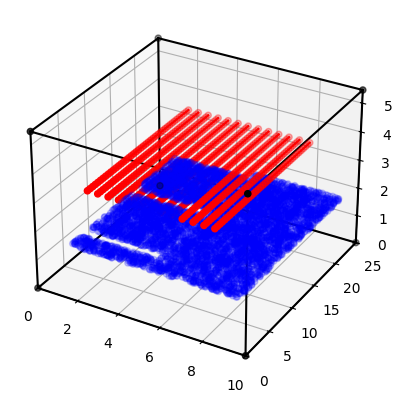

In [11]:
# Plot the room with the strip in it.
plotter.plot_room(config)

In [12]:
# Construct the waveform class based on the loaded configuration.
waveform_config = config["waveform_config"]
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

In [13]:
# Build all the RadioStripe objects based on the configuration.
stripes: list[RadioStripe] = []
component_config = config["component_config"]
stripe_cfg = config["radio_stripes"][0]
for stripe_cfg in config["radio_stripes"]:
    stripes.append(RadioStripe.from_config_locations(stripe_cfg, component_config, wf))

In [14]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)

In [15]:
# The UE has the same hardware as a central unit.
ue = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_ue = ue.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

# A single radio unit is used to represent the transmit stage of the ue. The UE position does not influence the
# transmission so we can set it arbitrarily.
ue_ru = RadioUnit(x=0, y=0, z=0, wf=wf)
# Transmit the data towards the stripe. We only perform this task once. Every UE in the room will transmit the same
# signal towards the stripe. Only its position and hence the channel will change.
shifts = [0, 0, 0, 0]
iq_data_tx, imdata = ue_ru.transmit(ofdm_time_after_ue, shifts)

In [18]:
# Loop over all the UE positions and perform an exhaustive search.
ue_data = []
for ue_pos in config["ue_positions"]:
    # Construct the wireless channel for this UE.
    channel = Channel.from_sionna(ue_pos)

    # Transmit the data over the channel and get the data at all the radio units.
    iq_data_rx = channel.transmit_ul(iq_data_tx, wf)

    # Now receive this data on all the stripes.
    for stripe_idx, (stripe, data) in enumerate(zip(stripes, iq_data_rx)):
        phase_shifts = [0, 0, 0, 0]
        for ru_idx in range(len(stripe.radio_units)):
            stripe.active_unit = ru_idx
            iq_out, imdata = stripe.receive(data, phase_shifts, delay=True)

            data_row = [channel.ue_idx, stripe_idx, ru_idx, iq_out.flatten()]
            ue_data.append(data_row)

    # Save the data to disk.
    df = pd.DataFrame(ue_data, columns=["ue_id", "stripe_id", "ru_id", "data"])
    df.to_pickle(f"flickering_data.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\projects\\6g-tandem\\sims\\6GTandem-simulator\\wireless_channel\\sionna_dataset\\sub_thz_channels\\channels_thz_ue_1.nc'

In [7]:
df = pd.read_pickle("flickering_data.pkl")
# Make a plot for every stripe. The plot is a heatmap with the data for every UE on the y-axis and the data for every
# RU on the x-axis.
for stripe_idx in df["stripe_id"].unique():
    # Get the data for this specific stripe.
    stripe_data = df.loc[df["stripe_id"] == stripe_idx,:]

    # Make a plot per stripe.
    #fig, ax = plt.subplots()
    for ue_idx in stripe_data["ue_id"].unique():
        # Get the data for this specific UE.
        ue_data = stripe_data.loc[stripe_data["ue_id"] == ue_idx,:]

        # Now iterate over all the data from the different RUs and plot it.
        for idx, rdata in ue_data.iterrows():
            pavg = np.mean(np.abs(rdata["data"]) ** 2)
            print(stripe_idx, ue_idx, rdata["ru_id"], pavg)
            #ax.plot(rdata["ru_id"], pavg)

0 0 0 6.087076330309032e-64
0 0 1 7.929923342487133e-17
0 0 2 4.9089691722985844e-17
0 0 3 4.900740242082189e-19
0 0 4 6.817126079116457e-20
0 0 5 8.437580014030482e-21
0 0 6 5.497287406303508e-22
0 0 7 3.499102401994308e-23
0 0 8 4.615795767054659e-24
0 0 9 5.098874834564805e-25
0 0 10 1.1235852036860814e-25
0 0 11 4.836231845192496e-27
0 0 12 4.339079324612037e-27
0 0 13 2.708603079763066e-28
0 0 14 5.408107612945305e-29
0 0 15 6.2274803743100815e-31
0 0 16 2.2175011010380713e-32
0 0 17 8.128304100676042e-34
0 0 18 7.364849372309599e-35
0 0 19 4.6031086573369415e-36
0 0 20 3.3991992077017013e-37
0 0 21 1.4716195345451828e-37
0 0 22 1.7105855676879455e-38
0 0 23 9.513266256404192e-40
0 0 24 4.930617061660148e-41
0 0 25 4.178810379405304e-43
0 0 26 3.4863040534486515e-44
0 0 27 3.6400249976028484e-45
0 0 28 1.682513807731102e-46
0 0 29 9.226360163879338e-48
0 0 30 8.283580301155064e-48
0 0 31 3.3265157569506065e-51
0 0 32 3.818386745723238e-51
0 0 33 4.756325640219944e-52
0 0 34 2.7137